In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
import sys
import os
sys.path.append(os.path.abspath(".."))
from core_ntsa.chhabra_algorithm import chhabra_jensen_spectrum
from core_ntsa.generators import simulate_lorenz
from core_ntsa.noise_tools import add_white_noise, add_colored_noise
from scipy.stats import linregress


lorenz_data = simulate_lorenz(t_span=50.0, dt=0.01)
clean_x = lorenz_data[0]

x_white_noise = add_white_noise(clean_x, snr_db=10.0)
x_clored_noise = add_colored_noise(clean_x, color='pink', snr_db=10.0)

# Chhabra Algorithm

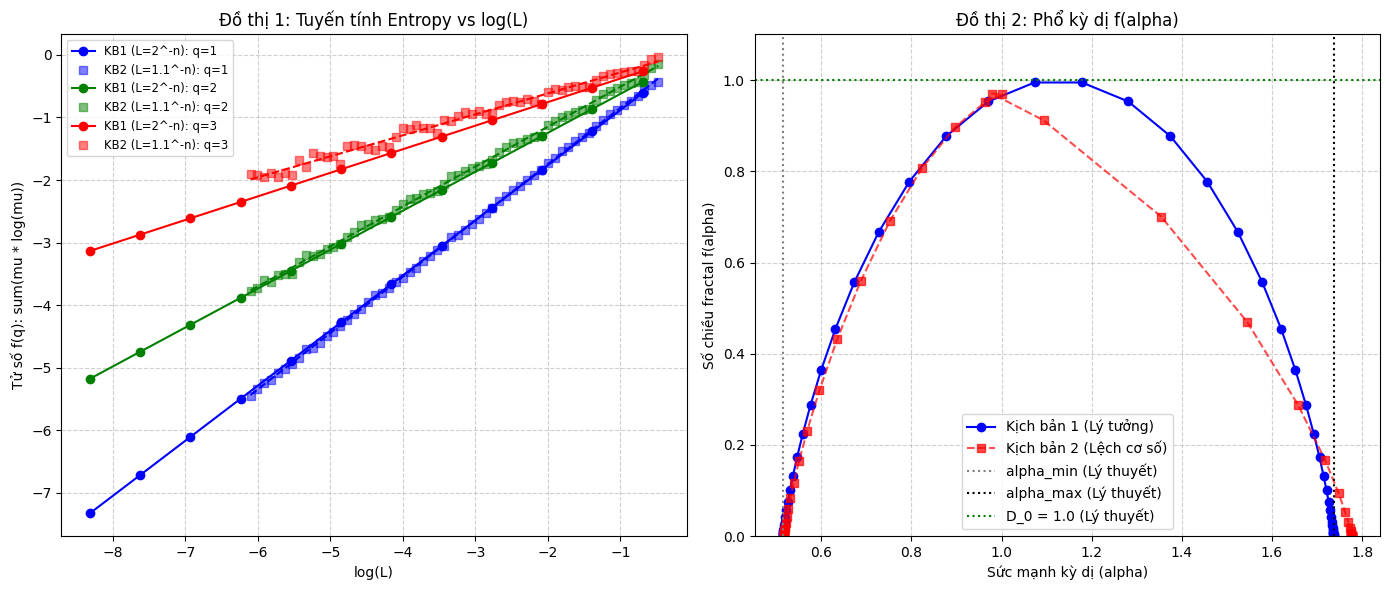

=== BÁO CÁO KIỂM THỬ GIẢI TÍCH ===
Alpha_min (Lý thuyết): 0.5146 | Thực nghiệm (KB1): 0.5148
Alpha_max (Lý thuyết): 1.7370 | Thực nghiệm (KB1): 1.7367
D_0 cực đại (q=0): 0.9946 (Tiêu chuẩn: 1.0000)


In [5]:
def get_entropy_numerator(prob_dict, q):
    """
    Hàm phụ trợ để trích xuất tử số entropy nhằm phục vụ vẽ Đồ thị 1.
    """
    scales = np.sort(list(prob_dict.keys()))
    numerators = np.zeros(len(scales))
    for j, L in enumerate(scales):
        P = prob_dict[L]
        P = P[P > 0]
        log_P = np.log(P)
        
        log_mu_unnorm = q * log_P
        log_mu_unnorm -= np.max(log_mu_unnorm)
        mu = np.exp(log_mu_unnorm)
        mu /= np.sum(mu)
        
        numerators[j] = np.sum(mu * np.log(mu))
    return np.log(scales), numerators

if __name__ == "__main__":
    # =================================================================
    # BƯỚC 1: TẠO DỮ LIỆU CANTOR 2 TỶ LỆ
    # =================================================================
    N_max = 12
    p1, p2 = 0.7, 0.3
    
    prob_dict_1 = {}
    P_current = np.array([1.0])
    
    for n in range(1, N_max + 1):
        P_new = np.zeros(2**n)
        P_new[0::2] = P_current * p1
        P_new[1::2] = P_current * p2
        P_current = P_new
        
        L = 2.0**(-n)
        prob_dict_1[L] = P_current

    # =================================================================
    # BƯỚC 2: THIẾT LẬP KỊCH BẢN THỰC TẾ (LỆCH CƠ SỐ)
    # =================================================================
    finest_P = prob_dict_1[2.0**(-N_max)]
    x_centers = (np.arange(2**N_max) + 0.5) * (2.0**(-N_max))
    
    prob_dict_2 = {}
    # Quét kích thước L = 1.1^-n, giới hạn không nhỏ hơn độ phân giải dữ liệu
    for n in range(5, 65): 
        L = 1.1**(-n)
        if L < 2.0**(-N_max + 2):
            break
            
        # Box-counting bằng cách gom điểm khối lượng vào các ô L
        box_indices = (x_centers / L).astype(int)
        P_box = np.bincount(box_indices, weights=finest_P)
        prob_dict_2[L] = P_box[P_box > 0]

    # =================================================================
    # BƯỚC 3: TÍNH TOÁN VÀ TRỰC QUAN HÓA (PLOTTING)
    # =================================================================
    q_test = [1, 2, 3]
    q_range = np.linspace(-10, 10, 50)
    
    # Tính phổ f(alpha) cho cả 2 kịch bản
    alpha_1, f_1 = chhabra_jensen_spectrum(prob_dict_1, q_range)
    alpha_2, f_2 = chhabra_jensen_spectrum(prob_dict_2, q_range)
    
    # Tính tọa độ giải tích lý thuyết để đối chiếu
    alpha_min_theory = np.log(p1) / np.log(0.5)
    alpha_max_theory = np.log(p2) / np.log(0.5)
    
    plt.figure(figsize=(14, 6))

    # --- Đồ thị 1: Semi-log Plot ---
    plt.subplot(1, 2, 1)
    colors = ['blue', 'green', 'red']
    for idx, q in enumerate(q_test):
        log_L_1, num_1 = get_entropy_numerator(prob_dict_1, q)
        log_L_2, num_2 = get_entropy_numerator(prob_dict_2, q)
        
        plt.plot(log_L_1, num_1, 'o-', color=colors[idx], label=f'KB1 (L=2^-n): q={q}')
        plt.plot(log_L_2, num_2, 's', color=colors[idx], alpha=0.5, label=f'KB2 (L=1.1^-n): q={q}')
        
        # Hồi quy tuyến tính cho kịch bản 2 để thấy rõ xu hướng dao động
        slope, intercept, _, _, _ = linregress(log_L_2, num_2)
        plt.plot(log_L_2, slope * log_L_2 + intercept, '--', color=colors[idx])

    plt.title("Đồ thị 1: Tuyến tính Entropy vs log(L)")
    plt.xlabel("log(L)")
    plt.ylabel("Tử số f(q): sum(mu * log(mu))")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize='small')

    # --- Đồ thị 2: Singularity Spectrum f(alpha) ---
    plt.subplot(1, 2, 2)
    plt.plot(alpha_1, f_1, 'o-', color='blue', label='Kịch bản 1 (Lý tưởng)')
    plt.plot(alpha_2, f_2, 's--', color='red', alpha=0.7, label='Kịch bản 2 (Lệch cơ số)')
    
    # Đánh dấu các mốc lý thuyết
    plt.axvline(alpha_min_theory, color='gray', linestyle=':', label='alpha_min (Lý thuyết)')
    plt.axvline(alpha_max_theory, color='black', linestyle=':', label='alpha_max (Lý thuyết)')
    plt.axhline(1.0, color='green', linestyle=':', label='D_0 = 1.0 (Lý thuyết)')
    
    plt.title("Đồ thị 2: Phổ kỳ dị f(alpha)")
    plt.xlabel("Sức mạnh kỳ dị (alpha)")
    plt.ylabel("Số chiều fractal f(alpha)")
    plt.ylim(0, 1.1)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()

    # In thông số kiểm định
    print("=== BÁO CÁO KIỂM THỬ GIẢI TÍCH ===")
    print(f"Alpha_min (Lý thuyết): {alpha_min_theory:.4f} | Thực nghiệm (KB1): {np.min(alpha_1):.4f}")
    print(f"Alpha_max (Lý thuyết): {alpha_max_theory:.4f} | Thực nghiệm (KB1): {np.max(alpha_1):.4f}")
    print(f"D_0 cực đại (q=0): {np.max(f_1):.4f} (Tiêu chuẩn: 1.0000)")